In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report


In [4]:

(X_train,y_train),(X_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5782s 34us/step


In [5]:
print(X_train.shape)
print(y_train.shape)


(50000, 32, 32, 3)
(50000, 1)


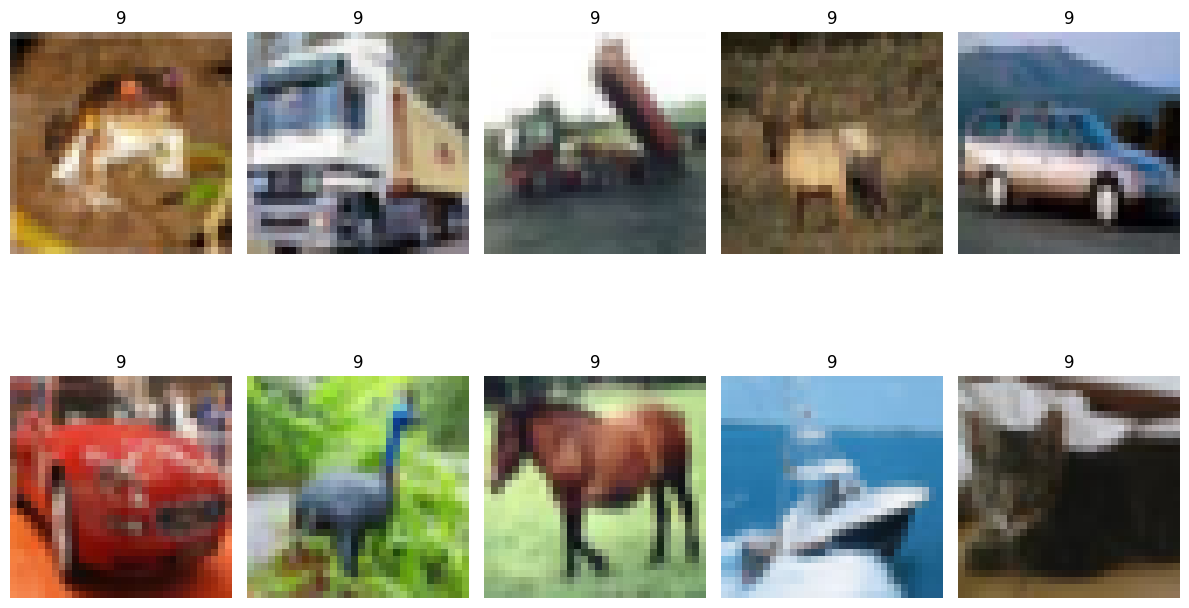

In [6]:
plt.figure(figsize=(12,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[1][0])
    plt.axis("off")
plt.tight_layout()

In [7]:
class_names = [
    "Airplane",
    "Automobiles",
    "bird",
    "cat",
    "Dog",
    "frog",
    "Horse",
    "Ship",
    "Truck"
]


In [8]:
print(X_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [9]:
X_train = X_train / 255.0

X_test = X_test / 255.0

print("Minimum : ",X_train.min())
print("Maximum : ",X_test.max())

Minimum :  0.0
Maximum :  1.0


In [18]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (2,3),
        activation="relu",
        input_shape=(32,32,3)
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=23,
    validation_split=0.2
)

print(history.history.keys())

Epoch 1/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.4486 - loss: 1.5296 - val_accuracy: 0.5463 - val_loss: 1.2830
Epoch 2/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.5840 - loss: 1.1836 - val_accuracy: 0.6016 - val_loss: 1.1407
Epoch 3/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.6307 - loss: 1.0575 - val_accuracy: 0.6405 - val_loss: 1.0448
Epoch 4/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.6617 - loss: 0.9660 - val_accuracy: 0.6384 - val_loss: 1.0360
Epoch 5/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.6871 - loss: 0.8981 - val_accuracy: 0.6523 - val_loss: 0.9921
Epoch 6/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.7110 - loss: 0.8315 - val_accuracy: 0.6462 - val_loss: 1.0448
Epoch 7/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.7292 - loss: 0.7784 - val_accuracy: 0.6498 - val_loss: 1.0462
Epoch 8/10
1740/1740 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.7441 -

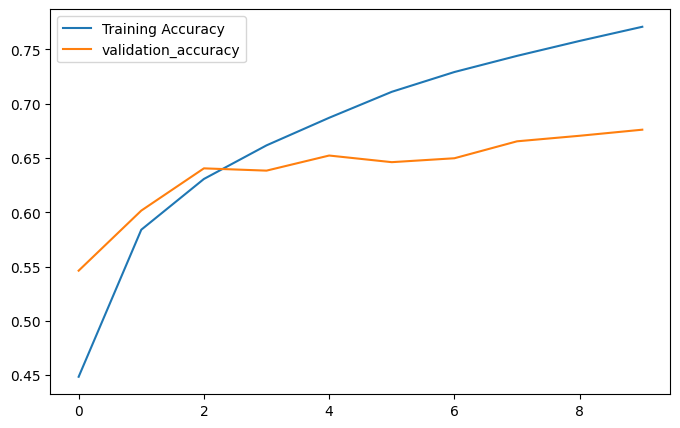

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="validation_accuracy")
plt.legend()
plt.show()

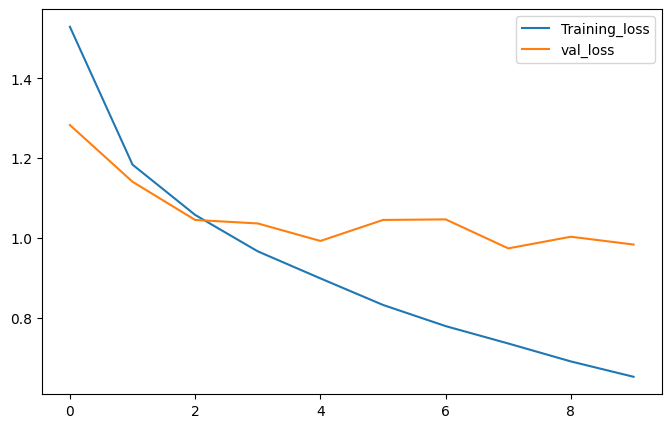

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

In [23]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [24]:
predicted_label = np.argmax(predictions[0])

print("Predicted Digit :", predicted_label)

print("Actual Digit :", y_test[0])


Predicted Digit : 3
Actual Digit : [3]


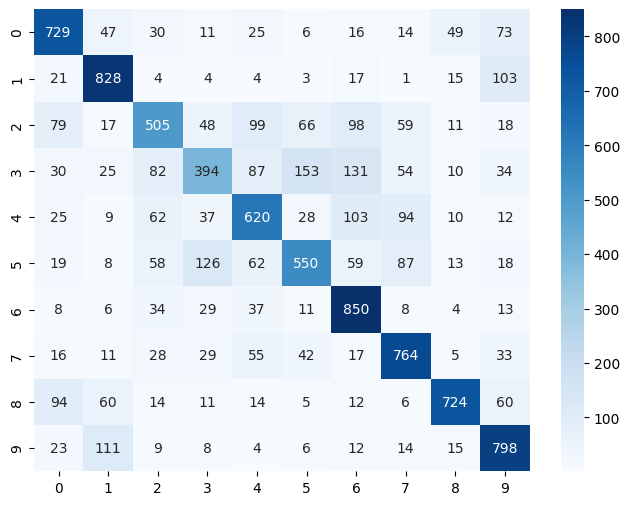

In [28]:
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.show()


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.73      0.71      1000
           1       0.74      0.83      0.78      1000
           2       0.61      0.51      0.55      1000
           3       0.57      0.39      0.46      1000
           4       0.62      0.62      0.62      1000
           5       0.63      0.55      0.59      1000
           6       0.65      0.85      0.73      1000
           7       0.69      0.76      0.73      1000
           8       0.85      0.72      0.78      1000
           9       0.69      0.80      0.74      1000

    accuracy                           0.68     10000
   macro avg       0.67      0.68      0.67     10000
weighted avg       0.67      0.68      0.67     10000

